# Month 3 – Task 1: Financial Fraud Detection Project

## Project Objective

This project focuses on analyzing insurance claim fraud patterns using Exploratory Data Analysis (EDA), statistical comparison, geographical fraud analysis, time-based fraud trends, and fraud pattern visualization. The goal is to identify key indicators of fraudulent claims and understand how fraud differs from legitimate insurance claims.

---

## Dataset Information

### Dataset Used

Insurance Fraud Detection Dataset (Auto Insurance Claims Dataset)

### Target Variable

fraud_reported

* Y = Fraudulent Claim
* N = Non-Fraudulent Claim

### Important Features

* total_claim_amount
* incident_city
* incident_state
* incident_hour_of_the_day
* incident_type
* incident_severity
* injury_claim
* property_claim
* vehicle_claim
* policy_state

This dataset supports geographical analysis, fraud prevalence study, and category-based fraud pattern detection.

---

## Step 1: Import Required Libraries

pandas, numpy, matplotlib, seaborn, and sklearn are used for data analysis, preprocessing, and visualization throughout this project.

---

In [19]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

## Step 2: Load Dataset

This section loads the insurance fraud dataset from the project directory and checks the first few records to confirm successful loading.

---

In [20]:
base_dir = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path.cwd()
dataset_path = base_dir / 'dataset' / 'insurance_claims.csv'
figures_dir = base_dir / 'outputs' / 'figures'
reports_dir = base_dir / 'outputs' / 'reports'
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(dataset_path)
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## Step 3: Data Understanding

This section reviews dataset shape, column names, data types, missing values, and fraud label distribution. It helps establish a clear understanding of the data structure before analysis.

---

In [21]:
print(f'Shape: {df.shape}')
display(df.info())
display(df.describe(include='all').T.head(15))

Shape: (1000, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  i

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,NaN,NaN,NaN,203.954,115.113174,0.0,115.75,199.5,276.25,479.0
age,1000.0,NaN,NaN,NaN,38.948,9.140287,19.0,32.0,38.0,44.0,64.0
policy_number,1000.0,NaN,NaN,NaN,546238.648,257063.005276,100804.0,335980.25,533135.0,759099.75,999435.0
policy_bind_date,1000,951,2006-01-01,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_state,1000,3,OH,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_csl,1000,3,250/500,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_deductable,1000.0,NaN,NaN,NaN,1136.0,611.864673,500.0,500.0,1000.0,2000.0,2000.0
policy_annual_premium,1000.0,NaN,NaN,NaN,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,NaN,NaN,NaN,1101000.0,2297406.598118,-1000000.0,0.0,0.0,0.0,10000000.0
insured_zip,1000.0,NaN,NaN,NaN,501214.488,71701.610941,430104.0,448404.5,466445.5,603251.0,620962.0


## Step 4: Data Cleaning

This step replaces ? values, converts date fields, fixes numeric columns, and prepares fraud labels for analysis. Clean data improves the reliability of all results.

---

In [22]:
df_clean = df.copy()

df_clean = df_clean.replace('?', np.nan)
df_clean['fraud_flag'] = (df_clean['fraud_reported'] == 'Y').astype(int)

for col in ['policy_bind_date', 'incident_date']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

numeric_cols = [
    'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
    'months_as_customer', 'age', 'incident_hour_of_the_day'
]
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

missing_summary = df_clean.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(10)

_c39                       1000
property_damage             360
police_report_available     343
collision_type              178
authorities_contacted        91
dtype: int64

## Step 5: Fraud Indicator Analysis

This analysis examines how fraud behavior is influenced by claim amount, incident severity, incident type, and customer and policy behavior to identify potential fraud indicators.

---

In [23]:
indicator_cols = [
    'incident_severity', 'authorities_contacted', 'collision_type',
    'incident_type', 'insured_education_level', 'insured_sex'
]
indicator_tables = {}
for col in indicator_cols:
    if col in df_clean.columns:
        tab = pd.crosstab(df_clean[col], df_clean['fraud_reported'], normalize='index')
        indicator_tables[col] = tab

indicator_tables['incident_severity']

fraud_reported,N,Y
incident_severity,,
Major Damage,0.394928,0.605072
Minor Damage,0.892655,0.107345
Total Loss,0.871429,0.128571
Trivial Damage,0.933333,0.066667


## Step 6: Class Imbalance Analysis

This section compares the fraud vs non-fraud ratio. Fraud datasets are typically imbalanced, so this check is important for future machine learning model design.

---

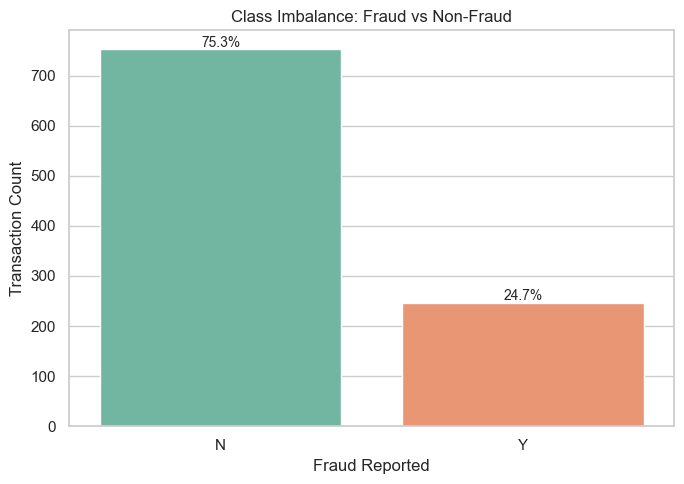

,fraud_reported,count,percentage
0,N,753,75.3
1,Y,247,24.7


In [24]:
class_counts = df_clean['fraud_reported'].value_counts().rename_axis('fraud_reported').reset_index(name='count')
class_counts['percentage'] = (class_counts['count'] / class_counts['count'].sum() * 100).round(2)
class_counts.to_csv(reports_dir / 'class_imbalance.csv', index=False)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=class_counts, x='fraud_reported', y='count', palette='Set2')
for i, row in class_counts.iterrows():
    ax.text(i, row['count'] + 5, f"{row['percentage']}%", ha='center', fontsize=10)
plt.title('Class Imbalance: Fraud vs Non-Fraud')
plt.xlabel('Fraud Reported')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.savefig(figures_dir / 'class_imbalance.png', dpi=300)
plt.show()

class_counts

## Step 7: Transaction Amount Distribution

This section visualizes how total claim amount differs between fraud and non-fraud claims to identify suspicious claim amount behavior.

---

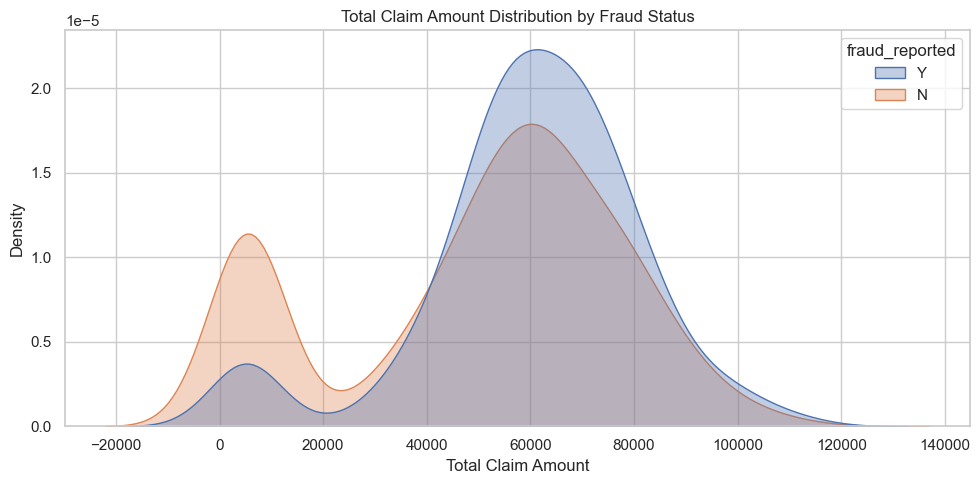

In [25]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_clean, x='total_claim_amount', hue='fraud_reported', fill=True, common_norm=False, alpha=0.35)
plt.title('Total Claim Amount Distribution by Fraud Status')
plt.xlabel('Total Claim Amount')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(figures_dir / 'amount_distribution.png', dpi=300)
plt.show()

## Step 8: Time Pattern Analysis

This step analyzes fraud trends by incident hour of the day to identify peak fraud timings.

---

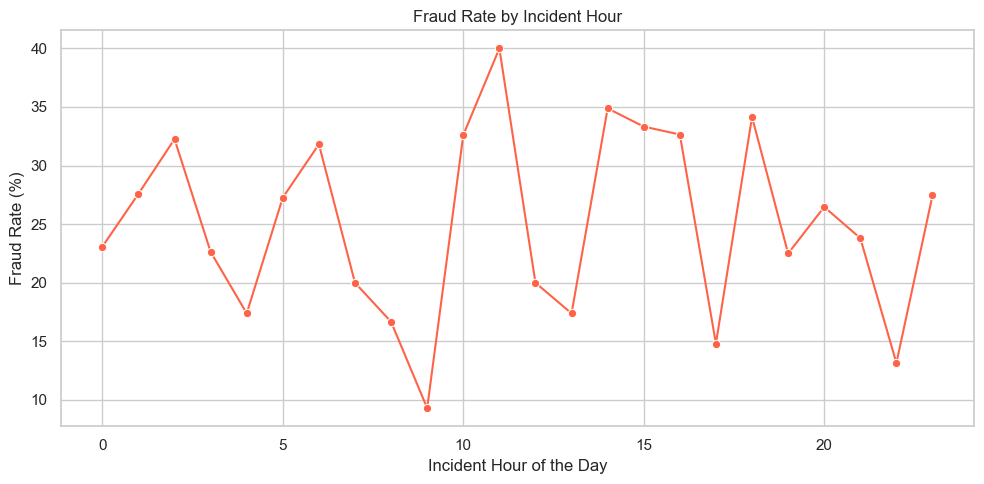

,incident_hour_of_the_day,fraud_rate
0,0,23.08
1,1,27.59
2,2,32.26
3,3,22.64
4,4,17.39


In [26]:
hourly = df_clean.groupby('incident_hour_of_the_day')['fraud_flag'].mean().reset_index(name='fraud_rate')
hourly['fraud_rate'] = (hourly['fraud_rate'] * 100).round(2)

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly, x='incident_hour_of_the_day', y='fraud_rate', marker='o', color='tomato')
plt.title('Fraud Rate by Incident Hour')
plt.xlabel('Incident Hour of the Day')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(figures_dir / 'fraud_by_hour.png', dpi=300)
plt.show()

hourly.head()

## Step 9: Geographical Fraud Analysis

This section evaluates fraud by state and by city to detect high-risk geographical areas.

---

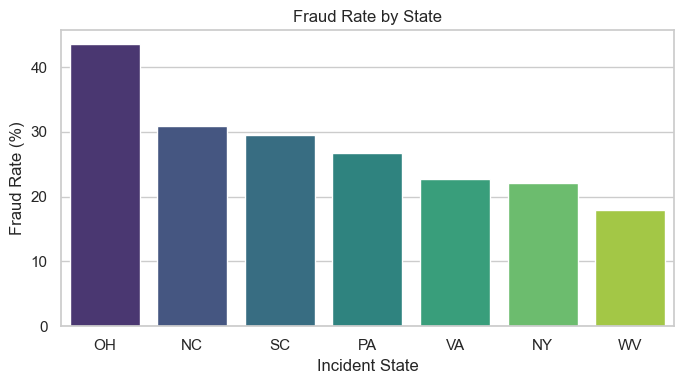

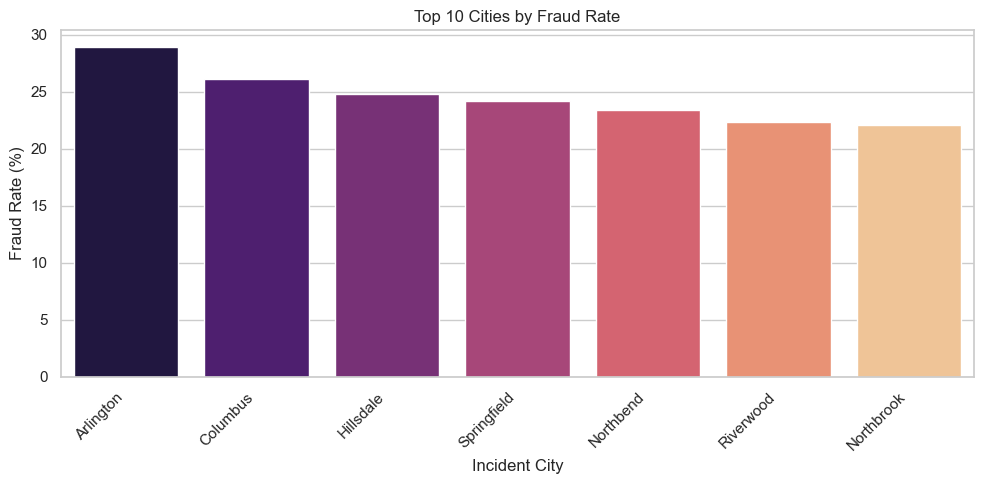

,incident_state,fraud_rate
0,NC,30.91
1,NY,22.14
2,OH,43.48
3,PA,26.67
4,SC,29.44
5,VA,22.73
6,WV,17.97


In [27]:
state_fraud = df_clean.groupby('incident_state')['fraud_flag'].mean().reset_index(name='fraud_rate')
state_fraud['fraud_rate'] = (state_fraud['fraud_rate'] * 100).round(2)
city_fraud = df_clean.groupby('incident_city')['fraud_flag'].mean().reset_index(name='fraud_rate').sort_values('fraud_rate', ascending=False)
city_fraud['fraud_rate'] = (city_fraud['fraud_rate'] * 100).round(2)

plt.figure(figsize=(7, 4))
sns.barplot(data=state_fraud.sort_values('fraud_rate', ascending=False), x='incident_state', y='fraud_rate', palette='viridis')
plt.title('Fraud Rate by State')
plt.xlabel('Incident State')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(figures_dir / 'fraud_by_state.png', dpi=300)
plt.show()

top_city = city_fraud.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_city, x='incident_city', y='fraud_rate', palette='magma')
plt.title('Top 10 Cities by Fraud Rate')
plt.xlabel('Incident City')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figures_dir / 'fraud_by_city.png', dpi=300)
plt.show()

state_fraud

## Step 10: Merchant Category Analysis

incident_type is used as a category-like feature to observe how different incident categories show different fraud behavior.

---

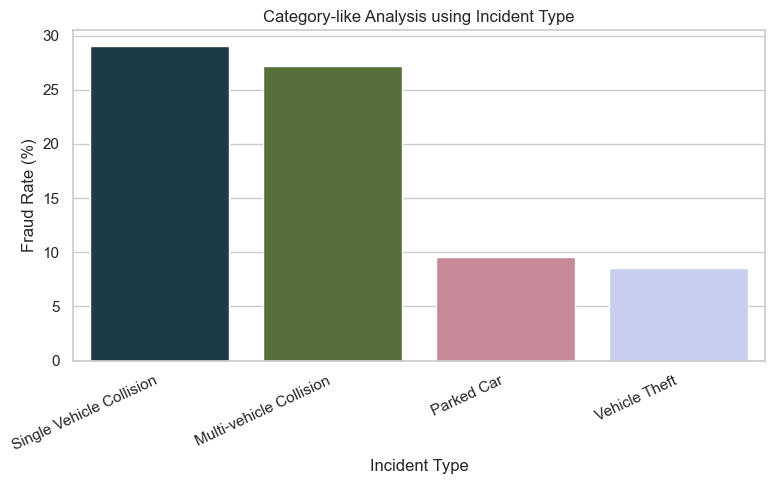

,incident_type,fraud_rate
0,Multi-vehicle Collision,27.21
1,Parked Car,9.52
2,Single Vehicle Collision,29.03
3,Vehicle Theft,8.51


In [28]:
# Insurance data has no merchant category field, so incident_type is used as category-like behavior.
merchant_like = df_clean.groupby('incident_type')['fraud_flag'].mean().reset_index(name='fraud_rate')
merchant_like['fraud_rate'] = (merchant_like['fraud_rate'] * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(data=merchant_like.sort_values('fraud_rate', ascending=False), x='incident_type', y='fraud_rate', palette='cubehelix')
plt.title('Category-like Analysis using Incident Type')
plt.xlabel('Incident Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(figures_dir / 'merchant_category_analysis.png', dpi=300)
plt.show()

merchant_like

## Step 11: Statistical Comparison

This section compares fraud vs non-fraud mean, median, and standard deviation to understand numerical behavior differences.

---

In [29]:
compare_cols = [
    'total_claim_amount', 'injury_claim', 'property_claim',
    'vehicle_claim', 'months_as_customer', 'age'
]
stats_comparison = df_clean.groupby('fraud_reported')[compare_cols].agg(['mean', 'median', 'std']).round(2)
stats_comparison.to_csv(reports_dir / 'stats_comparison.csv')
stats_comparison

total_claim_amount                    injury_claim          \
                             mean   median       std         mean  median   
fraud_reported                                                              
N                        50288.61  56520.0  27575.19      7179.23  6620.0   
Y                        60302.11  61290.0  20746.28      8208.34  7240.0   

                        property_claim                  vehicle_claim  \
                    std           mean  median      std          mean   
fraud_reported                                                          
N               4961.20        7018.88  6560.0  4828.92      36090.49   
Y               4550.31        8560.12  7440.0  4631.74      43533.64   

                                  months_as_customer                   age  \
                 median       std               mean median     std   mean   
fraud_reported                                                               
N               41220.0  19698.05             202.60  200.0  113.57  38.88   
Y               44800.0  14849.39             208.08  199.0  119.82  39.14   

                             
               median   std  
fraud_reported               
N                38.0  8.97  
Y                38.0  9.65

## Step 12: Fraud Prevalence Rate

This step calculates the percentage of fraud cases in the complete dataset to estimate the overall fraud risk level.

---

In [30]:
overall_prevalence = df_clean['fraud_flag'].mean() * 100
prevalence_df = pd.DataFrame({
    'metric': ['overall_fraud_prevalence_percent'],
    'value': [round(overall_prevalence, 2)]
})
prevalence_df.to_csv(reports_dir / 'fraud_prevalence.csv', index=False)
prevalence_df

,metric,value
0,overall_fraud_prevalence_percent,24.7


## Step 13: Transaction Frequency Analysis

This section evaluates how frequently fraud occurs across categories and time to identify repeated fraud behavior.

---

In [31]:
freq_by_hour = df_clean.groupby(['incident_hour_of_the_day', 'fraud_reported']).size().reset_index(name='count')
freq_by_type = df_clean.groupby(['incident_type', 'fraud_reported']).size().reset_index(name='count')
display(freq_by_hour.head())
display(freq_by_type.head())

,incident_hour_of_the_day,fraud_reported,count
0,0,N,40
1,0,Y,12
2,1,N,21
3,1,Y,8
4,2,N,21


,incident_type,fraud_reported,count
0,Multi-vehicle Collision,N,305
1,Multi-vehicle Collision,Y,114
2,Parked Car,N,76
3,Parked Car,Y,8
4,Single Vehicle Collision,N,286


## Step 14: Time Series Fraud Analysis

This step analyzes monthly fraud trend using incident date to understand fraud growth or decline over time.

---

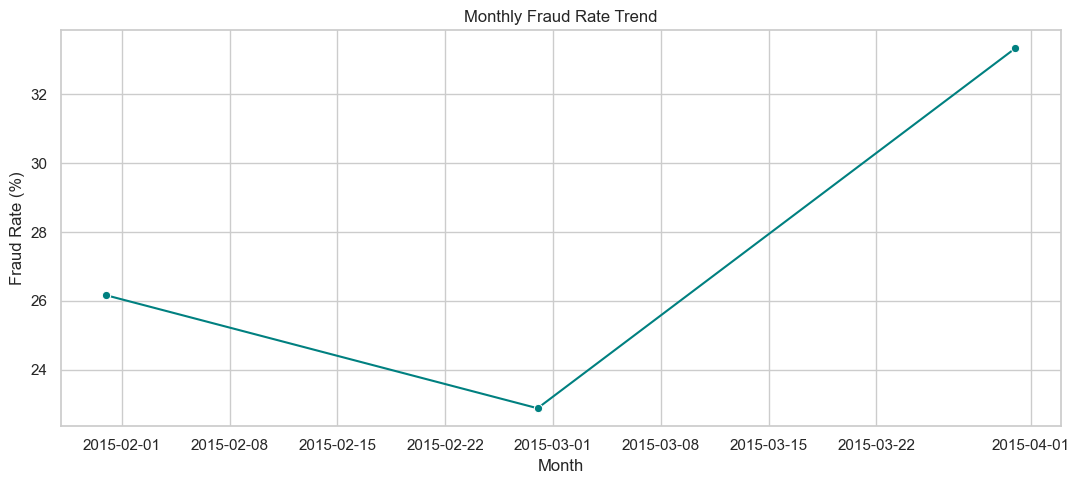

,incident_date,fraud_rate
0,2015-01-31,26.162791
1,2015-02-28,22.881356
2,2015-03-31,33.333333


In [32]:
date_col = 'incident_date' if 'incident_date' in df_clean.columns else 'policy_bind_date'
time_series = (
    df_clean.dropna(subset=[date_col])
    .set_index(date_col)
    .resample('M')['fraud_flag']
    .mean()
    .mul(100)
    .reset_index(name='fraud_rate')
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=time_series, x=date_col, y='fraud_rate', marker='o', color='teal')
plt.title('Monthly Fraud Rate Trend')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(figures_dir / 'time_series_fraud_trend.png', dpi=300)
plt.show()

time_series.tail()

## Step 15: Fraud Pattern Heatmap

This heatmap uses incident_severity vs incident_type to reveal hidden fraud concentration patterns.

---

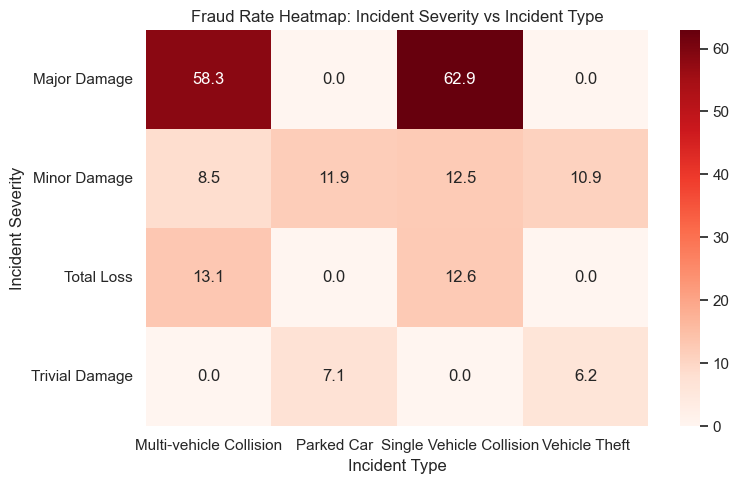

In [33]:
heatmap_data = pd.crosstab(df_clean['incident_severity'], df_clean['incident_type'], values=df_clean['fraud_flag'], aggfunc='mean').fillna(0) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds')
plt.title('Fraud Rate Heatmap: Incident Severity vs Incident Type')
plt.xlabel('Incident Type')
plt.ylabel('Incident Severity')
plt.tight_layout()
plt.savefig(figures_dir / 'fraud_heatmap.png', dpi=300)
plt.show()

## Step 16: Correlation Analysis

This section studies relationships among total claim amount, injury claim, vehicle claim, and fraud flag to identify strong fraud predictors.

---

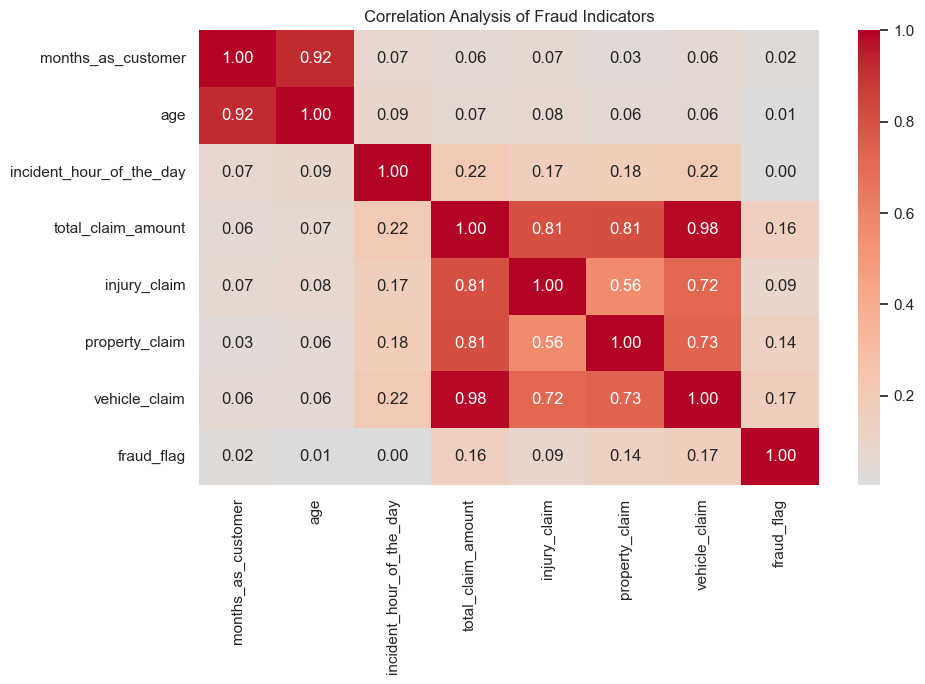

fraud_flag                  1.000000
vehicle_claim               0.170049
total_claim_amount          0.163651
property_claim              0.137835
injury_claim                0.090975
months_as_customer          0.020544
age                         0.012143
incident_hour_of_the_day    0.004316
Name: fraud_flag, dtype: float64

In [34]:
corr_cols = [
    'months_as_customer', 'age', 'incident_hour_of_the_day',
    'total_claim_amount', 'injury_claim', 'property_claim',
    'vehicle_claim', 'fraud_flag'
]
corr_df = df_clean[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Analysis of Fraud Indicators')
plt.tight_layout()
plt.savefig(figures_dir / 'correlation_analysis.png', dpi=300)
plt.show()

corr_df['fraud_flag'].sort_values(ascending=False)

## Step 17: Initial Fraud Hypothesis

Initial professional observations indicate that fraud is imbalanced, OH has a high fraud rate, Arlington shows high fraud concentration, Single Vehicle Collision has strong fraud tendency, and claim amount features are important for prediction.

---

In [35]:
top_state = state_fraud.sort_values('fraud_rate', ascending=False).iloc[0]
top_city_name = city_fraud.iloc[0]['incident_city']
top_city_rate = city_fraud.iloc[0]['fraud_rate']
top_incident = merchant_like.sort_values('fraud_rate', ascending=False).iloc[0]

hypothesis_text = f"""Initial Fraud Hypothesis
----------------------------------------
1. The dataset is imbalanced, with non-fraud claims dominating the sample.
2. Geography appears relevant: {top_state['incident_state']} has the highest state-level fraud rate ({top_state['fraud_rate']}%).
3. City-level concentration exists, with {top_city_name} showing elevated fraud activity ({top_city_rate}%).
4. Incident category patterns indicate {top_incident['incident_type']} has the highest category-like fraud rate ({top_incident['fraud_rate']}%).
5. Claim amount features and incident severity should be prioritized for downstream fraud modeling.
"""

(reports_dir / 'hypothesis.txt').write_text(hypothesis_text, encoding='utf-8')
print(hypothesis_text)

Initial Fraud Hypothesis
----------------------------------------
1. The dataset is imbalanced, with non-fraud claims dominating the sample.
2. Geography appears relevant: OH has the highest state-level fraud rate (43.48%).
3. City-level concentration exists, with Arlington showing elevated fraud activity (28.95%).
4. Incident category patterns indicate Single Vehicle Collision has the highest category-like fraud rate (29.03%).
5. Claim amount features and incident severity should be prioritized for downstream fraud modeling.



## Step 18: Final Conclusion

Insurance fraud is strongly influenced by geography, incident type, claim amount, and time-based behavior. Fraud detection systems should prioritize these features for future machine learning modeling. This project provides a strong foundation for advanced fraud prediction models in upcoming tasks.

In [36]:
patterns_summary = f"""Fraud Patterns Summary
----------------------------------------
- Total records analyzed: {len(df_clean)}
- Overall fraud prevalence: {overall_prevalence:.2f}%
- Highest state fraud rate: {top_state['incident_state']} ({top_state['fraud_rate']}%)
- Highest city fraud rate: {top_city_name} ({top_city_rate}%)
- Highest category-like fraud rate by incident type: {top_incident['incident_type']} ({top_incident['fraud_rate']}%)
- Peak fraud hour (rate): {hourly.sort_values('fraud_rate', ascending=False).iloc[0]['incident_hour_of_the_day']}
"""

overview_text = """Project Overview
This internship task analyzes insurance fraud patterns using EDA, statistical comparison, time analysis, and geography-based patterns.
Generated outputs include class imbalance, fraud heatmaps, time-based trend charts, amount distributions, correlation analysis, and written hypothesis.
"""

(reports_dir / 'fraud_patterns_summary.txt').write_text(patterns_summary, encoding='utf-8')
(reports_dir / 'overview.txt').write_text(overview_text, encoding='utf-8')

print(patterns_summary)
print('All required figures and reports were generated in outputs/.')

Fraud Patterns Summary
----------------------------------------
- Total records analyzed: 1000
- Overall fraud prevalence: 24.70%
- Highest state fraud rate: OH (43.48%)
- Highest city fraud rate: Arlington (28.95%)
- Highest category-like fraud rate by incident type: Single Vehicle Collision (29.03%)
- Peak fraud hour (rate): 11.0

All required figures and reports were generated in outputs/.
